<hr style="border:2px solid gray"> </hr>

# Traveling Salesman Problem

## Example Code

### Algorithm 3: Simulated Annealing

<hr style="border:2px solid gray"> </hr>

In [ ]:
# package list
import numpy as np
import sys
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import time
import random
import functools

# Global Variables
# SA
TEMPERATURE = 9999999999
COOLING_RATIO = 0.99
TEMP_LIMIT = 1

# Plot Settings
PLOT_MODE = True # Draw Route
plt.ion()

# First City Index
FIRST_IDX = 0

In [ ]:
#important! 여기는 수정 금지
def timing(func):
    """함수 실행 시간을 측정하는 데코레이터"""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"{func.__name__} 실행 시간: {end - start:.6f} 초")
        return result
    return wrapper

SEED = 42
np.random.seed(SEED)   # numpy 전역 시드
random.seed(SEED)      # 파이썬 내장 random 시드

In [ ]:
file_path = 'data1.txt'

# Step 1. Data Loading

In [ ]:
def fileloader():
    #     Data Format
    #     ---------------------------------------------------------
    #     NAME : pia3056
    #     COMMENT : Bonn VLSI data set with 3056 points
    #     COMMENT : Uni Bonn, Research Institute for Discrete Math
    #     COMMENT : Contributed by Andre Rohe
    #     TYPE : TSP
    #     DIMENSION : 3056 -----------------------------|
    #     EDGE_WEIGHT_TYPE : EUC_2D                     |
    #     NODE_COORD_SECTION                            |
    #     1 0 11 (2 dimentional coordinate of city)     |
    #     2 0 115                                       |
    #     ...                                           |
    #     ...(Total 3056 nodes)<------------------------|
    #     EOF
    #     ---------------------------------------------------------
    with open(file_path, "r") as file:
        file_str = file.readlines()

    # Get the coordinates of cities
    coord_str = file_str[8:-1]  # first city string to last city string (EOF 전까지)
    coord_list = np.zeros((len(coord_str), 2))
    for idx, item in enumerate(coord_str):
        items = item.split()
        coord_list[idx, 0], coord_list[idx, 1] = float(items[1]), float(items[2])

    return coord_list

# Step 2. Initialization

In [ ]:
def initialize_greedy(coord_list, first_idx):
    cnt_cities = len(coord_list)
    # Initialize path and insert first city index to the first and last elements
    path = np.zeros(cnt_cities + 1, dtype=np.int32)
    path[0], path[-1] = first_idx, first_idx

    # Euclidean distance map between cities
    path_map = euclidean_distances(coord_list, coord_list)

    cities_tovisit = np.ones((cnt_cities), dtype=np.bool_)
    cities_tovisit[first_idx] = False

    # Iteratively Connect nearest cities
    for i in range(1, cnt_cities):
        start_idx = path[i - 1]
        distance_from_start = path_map[start_idx, :]
        nearest_list = np.argsort(distance_from_start)
        for idx in range(len(nearest_list)):
            # check the nearest city is visited
            if cities_tovisit[nearest_list[idx]]:
                nearest_city = nearest_list[idx]
                break
        cities_tovisit[nearest_city] = False
        path[i] = nearest_city

    return path_map, path


def initialize_random(coord_list, first_idx):
    cnt_cities = len(coord_list)
    path = np.zeros(cnt_cities + 1, dtype=int)

    path[0], path[-1] = first_idx, first_idx
    # Euclidean distance map between cities
    path_map = euclidean_distances(coord_list, coord_list)

    # city indices without first city index
    cities_tovisit = np.delete(np.arange(cnt_cities), first_idx)
    cities_random = np.random.permutation(cities_tovisit)
    path[1:-1] = cities_random

    return path_map, path

def path_cost(path_map, path):
    # The array of cost between cities in the path
    cnt_cities = path_map.shape[0]
    cost_arr = np.zeros(cnt_cities)
    for i in range(cnt_cities):
        cost_arr[i] = path_map[path[i], path[i+1]]

    return cost_arr

In [ ]:
# Initialization ###############
initialize = initialize_greedy
#initialize = initialize_random
################################

# Step 3. Searching a path

## Algorithm 2. Hill Climbing (2-opt search)

In [ ]:
def sa(path_map, path):
    # SA with 2-opt swap (Optimized with Delta Calculation)
    cnt_cities = path_map.shape[0]

    # 초기 해 (current)
    cost_arr = path_cost(path_map, path)
    curr_path = path.copy()
    curr_cost = cost_arr.sum()

    # 최고 해 (best)
    best_path = curr_path.copy()
    best_cost = curr_cost

    temperature = TEMPERATURE
    while temperature > TEMP_LIMIT:
        # Select two indices of flip points (2-opt)
        i, j = np.sort(np.random.choice(np.arange(1, cnt_cities), 2))

        # 전체 비용을 다시 계산하는 대신, 변경되는 부분의 비용 차이만 계산합니다.


        p = curr_path

        original_cost = path_map[p[i-1], p[i]] + path_map[p[p.shape[0]-1 if j == p.shape[0]-1 else j-1], p[j]]
        new_swap_cost = path_map[p[i-1], p[p.shape[0]-1 if j == p.shape[0]-1 else j-1]] + path_map[p[i], p[j]]

        delta = new_swap_cost - original_cost



        if delta <= 0:
            # 개선된 경우 무조건 수용
            curr_path[i:j] = np.flip(curr_path[i:j])
            curr_cost += delta
        else:
            # 악화된 경우 확률적으로 수용
            prob = np.exp(-delta / float(temperature))
            if prob > np.random.rand():
                curr_path[i:j] = np.flip(curr_path[i:j])
                curr_cost += delta

        # 최고 해 갱신
        if curr_cost < best_cost:
            best_path, best_cost = curr_path.copy(), curr_cost

        # 온도 감소
        temperature *= COOLING_RATIO

    return best_path, best_cost

In [ ]:
@timing
def alg(coord_list):
    # 이 셀 이전에 initialize = initialize_greedy 로 설정해주세요.

    best_cost_overall = float('inf')
    best_path_overall = None
    num_cities = len(coord_list)

    print(f"총 {num_cities}개의 모든 도시를 시작점으로 탐색합니다 (정밀 탐색 모드)...")

    for i in range(num_cities):
        # i를 새로운 시작점으로 하여 탐색
        path_map, path = initialize(coord_list, i)
        new_path, new_cost = sa(path_map, path)

        # 10번마다 진행 상황 출력
        if (i + 1) % 10 == 0 or i == num_cities - 1:
            print(f"[{i + 1}/{num_cities}] 시작 도시 {i} 탐색 완료, 현재까지 최적 cost: {best_cost_overall}")

        if new_cost < best_cost_overall:
            best_cost_overall = new_cost
            best_path_overall = new_path
            print(f"*** 새로운 최적의 cost 발견: {best_cost_overall} (시작 도시: {i}) ***")

    # 최종적으로 가장 좋았던 경로를 시각화
    if PLOT_MODE:
        plt.close()
        figure, ax = plt.subplots()
        plt.scatter(coord_list[:, 0], coord_list[:, 1], c='red', s=10)
        plt.title('City Route')
        coord_path = coord_list.copy()
        coord_path = np.append(coord_path, coord_path[best_path_overall[0], :].reshape(1, 2), axis=0)
        coord_path[:, :] = coord_path[best_path_overall, :]
        lines, = ax.plot(coord_path[:, 0], coord_path[:, 1], 'k--')
        figure.canvas.draw()
        figure.canvas.flush_events()
        plt.show()

    return best_path_overall, best_cost_overall

# Main

총 131개의 모든 도시를 시작점으로 탐색합니다 (정밀 탐색 모드)...
*** 새로운 최적의 cost 발견: 706.000867290727 (시작 도시: 0) ***
*** 새로운 최적의 cost 발견: 701.6547266941818 (시작 도시: 1) ***
*** 새로운 최적의 cost 발견: 700.411590868211 (시작 도시: 2) ***
*** 새로운 최적의 cost 발견: 694.2513921377509 (시작 도시: 3) ***
[10/131] 시작 도시 9 탐색 완료, 현재까지 최적 cost: 694.2513921377509
[20/131] 시작 도시 19 탐색 완료, 현재까지 최적 cost: 694.2513921377509
[30/131] 시작 도시 29 탐색 완료, 현재까지 최적 cost: 694.2513921377509
[40/131] 시작 도시 39 탐색 완료, 현재까지 최적 cost: 694.2513921377509
*** 새로운 최적의 cost 발견: 688.983611260813 (시작 도시: 45) ***
[50/131] 시작 도시 49 탐색 완료, 현재까지 최적 cost: 688.983611260813
[60/131] 시작 도시 59 탐색 완료, 현재까지 최적 cost: 688.983611260813
*** 새로운 최적의 cost 발견: 684.3488428074338 (시작 도시: 63) ***
*** 새로운 최적의 cost 발견: 683.9542696514416 (시작 도시: 67) ***
[70/131] 시작 도시 69 탐색 완료, 현재까지 최적 cost: 683.9542696514416
*** 새로운 최적의 cost 발견: 674.4270054547342 (시작 도시: 77) ***
[80/131] 시작 도시 79 탐색 완료, 현재까지 최적 cost: 674.4270054547342
[90/131] 시작 도시 89 탐색 완료, 현재까지 최적 cost: 674.4270054547342
*** 새로운 최적의 cost

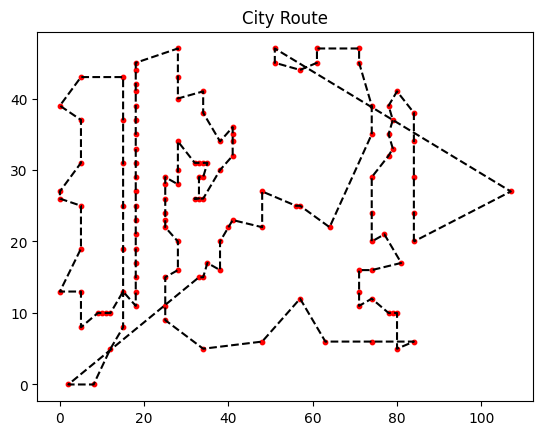

alg 실행 시간: 11.891438 초
Path: [124, 125, 126, 127, 128, 121, 116, 119, 115, 118, 114, 108, 107, 106, 112, 123, 105, 101, 100, 99, 104, 113, 117, 120, 122, 129, 111, 97, 92, 88, 73, 52, 44, 45, 53, 54, 46, 47, 48, 49, 50, 51, 55, 56, 57, 62, 66, 70, 75, 69, 65, 64, 61, 68, 78, 82, 83, 84, 85, 79, 71, 72, 58, 59, 60, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 18, 16, 15, 14, 13, 11, 5, 0, 6, 7, 1, 2, 8, 9, 3, 10, 23, 22, 21, 20, 19, 24, 17, 12, 4, 63, 67, 74, 76, 77, 80, 81, 86, 87, 91, 93, 98, 109, 110, 102, 103, 96, 95, 94, 89, 90, 130, 124]
Cost: 633.657174240393


In [ ]:
# important! 수정 금지
try:
    coord_list = fileloader()
except Exception as e:
    print('예외 발생', e)
    sys.exit()

best_path, best_cost = alg(coord_list)

print('Path: ' + str(best_path.tolist()))
print('Cost: ' + str(best_cost))